# Measure review: distribution fit and saturation

**Arno's five baseline sessions** (31 August; 1, 8, 18 and 23 September 2026). Prepared on 30 September 2026 for the discussion with Zhongxin.

This notebook answers two questions from the [3 September meeting](../docs/meetings/Academic_Supervisor_Meeting_Notes_2026-09-03.md):

1. **Fit:** do the recorded episode durations fit a distribution, and does the fit stay the same when one day is left out?
2. **Saturation:** do later days still add new kinds of work?

**How to read it.** This is a retrospective check: the rules were set after the data had been seen. All results are provisional and none of them selects an improvement candidate. No row is dropped from the data; each result is shown for **A. all data** and **B. without EXC**, because the EXC decision is still open.

**Data:** `output/Arno_Combined_2026-09-30.csv` and `output/Kinds_Of_Work_Rows_2026-09-30.csv`, built by the scripts in this folder. To rerun: `pip install numpy scipy pandas matplotlib`, then run all cells from the `analysis/` folder.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize

HERE = Path.cwd()
OUT = HERE / "output" if (HERE / "output").exists() else HERE / "analysis" / "output"
rows = pd.read_csv(OUT / "Arno_Combined_2026-09-30.csv")
kinds = pd.read_csv(OUT / "Kinds_Of_Work_Rows_2026-09-30.csv", keep_default_na=False)

DAYS = ["2026-08-31", "2026-09-01", "2026-09-08", "2026-09-18", "2026-09-23"]
LABEL = dict(zip(DAYS, ["31 Aug", "1 Sep", "8 Sep", "18 Sep", "23 Sep"]))
NET_MINUTES = dict(zip(DAYS, [165, 186, 104, 240, 197]))   # confirmed net observation

# Chart style: light surface, recessive grid, validated categorical colours in fixed order.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": "#c3c2b7", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "#e1e0d9", "grid.linewidth": 1,
    "lines.linewidth": 2, "lines.markersize": 7, "legend.frameon": False, "font.size": 10,
})

per_day = pd.DataFrame({
    "Day": [LABEL[d] for d in DAYS],
    "Net observed min": [NET_MINUTES[d] for d in DAYS],
    "Rows": [int((rows.date == d).sum()) for d in DAYS],
    "Timed rows": [int(((rows.date == d) & (rows.timed == 1)).sum()) for d in DAYS],
    "Recorded min": [int(rows.loc[rows.date == d, "minutes"].sum()) for d in DAYS],
    "of which EXC": [int(rows.loc[(rows.date == d) & (rows.flag_exc == 1), "minutes"].sum()) for d in DAYS],
})
per_day.loc[len(per_day)] = ["Total"] + per_day.iloc[:, 1:].sum().tolist()
per_day

,Day,Net observed min,Rows,Timed rows,Recorded min,of which EXC
0,31 Aug,165,63,39,103,4
1,1 Sep,186,50,43,162,38
2,8 Sep,104,42,38,106,27
3,18 Sep,240,74,57,196,47
4,23 Sep,197,58,48,185,66
5,Total,892,287,225,752,182


## 1. Do episode durations fit a distribution?

Most episodes last 1 to 3 minutes and a few last much longer, so durations are **right-skewed**. The first cell shows why a normal distribution does not suit them. The notebook then compares four distributions commonly used for positive durations: **exponential, gamma, lognormal and Weibull**.

Two features of how the data were recorded are built into the fit:

- **Whole minutes from a clock.** A duration is the difference between two clock readings, so a recorded 2 minutes means a true duration between 1 and 3 minutes.
- **Tallies.** Work that stayed within one clock minute was recorded as an untimed tally, so every timed episode has at least 1 recorded minute.

Each model is fitted by maximum likelihood and the models are compared with **AIC** (lower is better; a difference of more than about 4 to 7 is clear support). The best model is then checked by comparing observed and expected counts. The two lost-focus rows of 8 September are left out of the fit.

In [2]:
timed = rows[(rows.timed == 1) & (rows.flag_lost_focus == 0)]
VIEWS = {"A. All data": timed, "B. Without EXC": timed[timed.flag_exc == 0]}

x = timed.minutes.to_numpy(float)
print(f"All timed episodes: n = {len(x)}, mean {x.mean():.2f} min, median {np.median(x):.0f} min, skewness {stats.skew(x):.1f}")
print(f"A normal distribution with this mean and spread would put {stats.norm.cdf(-x.mean() / x.std(ddof=1)):.0%} "
      "of episodes below zero minutes, so it is not a sensible model for these durations.")

All timed episodes: n = 223, mean 3.33 min, median 2 min, skewness 5.9
A normal distribution with this mean and spread would put 19% of episodes below zero minutes, so it is not a sensible model for these durations.


In [3]:
MODELS = ["Exponential", "Gamma", "Lognormal", "Weibull"]
STEP = 0.01

def make_dist(name, p):
    if name == "Exponential": return stats.expon(scale=np.exp(p[0]))
    if name == "Gamma":       return stats.gamma(np.exp(p[0]), scale=np.exp(p[1]))
    if name == "Lognormal":   return stats.lognorm(np.exp(p[1]), scale=np.exp(p[0]))
    if name == "Weibull":     return stats.weibull_min(np.exp(p[0]), scale=np.exp(p[1]))

def recorded_pmf(dist, ks):
    """P(recorded minutes = k | at least 1 recorded minute).

    With clock readings, a true duration t is recorded as k with weight 1 - |t - k|, which gives
    P(k) = H(k+1) - 2H(k) + H(k-1), where H is the integral of the CDF."""
    ks = np.asarray(ks, float)
    t = np.arange(0, ks.max() + 1 + STEP / 2, STEP)
    F = dist.cdf(t)
    H = np.concatenate([[0], np.cumsum((F[1:] + F[:-1]) / 2 * STEP)])
    h = lambda v: np.interp(np.clip(v, 0, None), t, H)
    p = h(ks + 1) - 2 * h(ks) + h(ks - 1)
    return np.clip(p, 1e-300, None) / (1 - h(np.array([1.0]))[0])

def fit(name, minutes):
    ks, counts = np.unique(minutes, return_counts=True)
    m, v, lm = minutes.mean(), minutes.var(), np.log(minutes)
    start = {"Exponential": [np.log(m)], "Gamma": [np.log(m * m / v), np.log(v / m)],
             "Lognormal": [lm.mean(), np.log(lm.std())], "Weibull": [np.log(1.2), np.log(m)]}[name]
    nll = lambda p: -(counts * np.log(recorded_pmf(make_dist(name, p), ks))).sum()
    best = optimize.minimize(nll, start, method="Nelder-Mead", options={"xatol": 1e-6, "fatol": 1e-8, "maxiter": 4000})
    return make_dist(name, best.x), 2 * len(start) + 2 * best.fun

fits, table = {}, []
for view, data in VIEWS.items():
    minutes = data.minutes.to_numpy(float)
    results = {name: fit(name, minutes) for name in MODELS}
    best_aic = min(aic for _, aic in results.values())
    fits[view] = results
    for name, (dist, aic) in sorted(results.items(), key=lambda kv: kv[1][1]):
        table.append([view, len(minutes), name, round(aic, 1), round(aic - best_aic, 1),
                      round(dist.median(), 2), round(dist.mean(), 2), round(dist.ppf(0.9), 1)])
pd.DataFrame(table, columns=["View", "Episodes", "Model", "AIC", "Δ AIC", "Fitted median (min)",
                             "Fitted mean (min)", "90% shorter than (min)"])

,View,Episodes,Model,AIC,Δ AIC,Fitted median (min),Fitted mean (min),90% shorter than (min)
0,A. All data,223,Lognormal,889.0,0.0,2.26,3.09,6.2
1,A. All data,223,Exponential,909.9,20.9,1.94,2.80,6.5
2,A. All data,223,Weibull,910.3,21.3,1.72,2.68,6.4
3,A. All data,223,Gamma,911.9,22.9,1.92,2.79,6.5
4,B. Without EXC,183,Lognormal,703.8,0.0,2.11,2.88,5.8
5,B. Without EXC,183,Exponential,710.5,6.7,1.76,2.53,5.8
6,B. Without EXC,183,Weibull,712.4,8.6,1.69,2.50,5.8
7,B. Without EXC,183,Gamma,712.4,8.6,1.82,2.57,5.8


In [4]:
BINS = [(1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 7), (8, 10_000)]
BIN_LABELS = ["1", "2", "3", "4", "5", "6–7", "8+"]

def observed_expected(view):
    minutes = VIEWS[view].minutes.to_numpy(float)
    dist = fits[view]["Lognormal"][0]
    ks = np.arange(1, 10_001)
    p = recorded_pmf(dist, ks)
    obs = [int(((minutes >= a) & (minutes <= b)).sum()) for a, b in BINS]
    exp = [len(minutes) * p[(ks >= a) & (ks <= b)].sum() for a, b in BINS]
    return obs, exp

check = []
for view in VIEWS:
    obs, exp = observed_expected(view)
    chi2 = sum((o - e) ** 2 / e for o, e in zip(obs, exp))
    df = len(BINS) - 1 - 2
    check.append([view, " / ".join(map(str, obs)), " / ".join(f"{e:.1f}" for e in exp), round(chi2, 2), df,
                  round(stats.chi2.sf(chi2, df), 2)])
print("Lognormal fit: observed and expected episodes per duration bin (" + ", ".join(BIN_LABELS) + " minutes)")
pd.DataFrame(check, columns=["View", "Observed", "Expected", "Chi-square", "df", "p"])

Lognormal fit: observed and expected episodes per duration bin (1, 2, 3, 4, 5, 6–7, 8+ minutes)


,View,Observed,Expected,Chi-square,df,p
0,A. All data,54 / 70 / 32 / 23 / 16 / 14 / 14,59.3 / 57.8 / 37.5 / 23.2 / 14.5 / 15.5 / 15.2,4.23,4,0.38
1,B. Without EXC,52 / 53 / 25 / 21 / 13 / 9 / 10,53.5 / 48.6 / 30.1 / 18.0 / 11.0 / 11.4 / 10.5,2.70,4,0.61


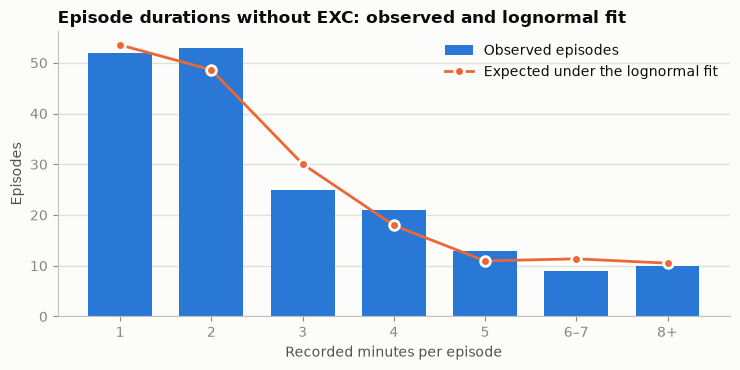

In [5]:
view = "B. Without EXC"
obs, exp = observed_expected(view)
pos = np.arange(len(BINS))
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.bar(pos, obs, width=0.7, color=SERIES[0], label="Observed episodes", zorder=2)
ax.plot(pos, exp, color=SERIES[1], marker="o", markeredgecolor="#fcfcfb", markeredgewidth=2,
        label="Expected under the lognormal fit", zorder=3)
ax.set_xticks(pos, BIN_LABELS)
ax.set_xlabel("Recorded minutes per episode")
ax.set_ylabel("Episodes")
ax.set_title("Episode durations without EXC: observed and lognormal fit")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc="upper right")
plt.tight_layout()
plt.show()

**Reading.** The **lognormal** fits best in both views, clearly ahead of the other three (Δ AIC about 21 with all data and about 7 without EXC). The observed-versus-expected check shows no misfit (p = 0.38 with all data, 0.61 without EXC). The fitted median episode is about 2 minutes, and 90% of episodes are shorter than about 6 minutes.

**Limits.** The chi-square p-values are approximate: the parameters are estimated from the same data, and several episodes belong to the same case, so episodes are not fully independent. The fit supports the stability check below; it does not replace it.

## 2. Is the fit stable when one day is left out?

The lognormal is refitted five times, each time leaving out one day, and compared with the fit on all five days. "Largest shift" is the biggest difference between the two fitted curves at any duration: 0.02 means that, for every duration, the share of episodes that short or shorter moves by at most 2 percentage points. Leaving out 23 September is the same as fitting days 1 to 4, so that row also shows what adding day 5 changed.

In [6]:
grid = np.linspace(0, 30, 3001)
loo, curves = [], {}
for view, data in VIEWS.items():
    reference = fits[view]["Lognormal"][0]
    for day in DAYS:
        dist, _ = fit("Lognormal", data.loc[data.date != day, "minutes"].to_numpy(float))
        curves[(view, day)] = dist
        loo.append([view, f"without {LABEL[day]}" + (" (= days 1–4)" if day == DAYS[-1] else ""),
                    int((data.date != day).sum()), round(dist.median(), 2), round(dist.mean(), 2),
                    round(dist.ppf(0.9), 1), round(np.abs(dist.cdf(grid) - reference.cdf(grid)).max(), 3)])
loo = pd.DataFrame(loo, columns=["View", "Left out", "Episodes", "Fitted median (min)", "Fitted mean (min)",
                                 "90% shorter than (min)", "Largest shift vs all five days"])
loo

,View,Left out,Episodes,Fitted median (min),Fitted mean (min),90% shorter than (min),Largest shift vs all five days
0,A. All data,without 31 Aug,184,2.36,3.22,6.5,0.021
1,A. All data,without 1 Sep,180,2.24,3.00,6.0,0.011
2,A. All data,without 8 Sep,187,2.27,3.19,6.5,0.011
3,A. All data,without 18 Sep,166,2.20,3.02,6.1,0.013
4,A. All data,without 23 Sep (= days 1–4),175,2.23,3.01,6.0,0.009
5,B. Without EXC,without 31 Aug,146,2.18,2.97,6.0,0.017
6,B. Without EXC,without 1 Sep,150,2.12,2.78,5.4,0.021
7,B. Without EXC,without 8 Sep,153,2.14,3.01,6.2,0.016
8,B. Without EXC,without 18 Sep,139,2.06,2.79,5.6,0.013
9,B. Without EXC,without 23 Sep (= days 1–4),144,2.03,2.84,5.8,0.022


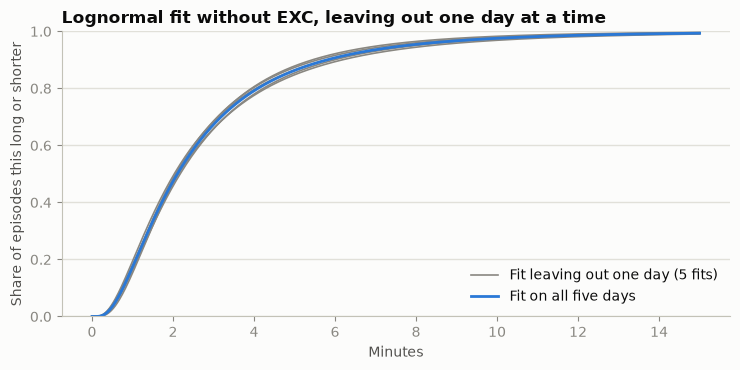

In [7]:
view = "B. Without EXC"
t = np.linspace(0, 15, 600)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for i, day in enumerate(DAYS):
    ax.plot(t, curves[(view, day)].cdf(t), color=MUTED, linewidth=1.2,
            label="Fit leaving out one day (5 fits)" if i == 0 else None)
ax.plot(t, fits[view]["Lognormal"][0].cdf(t), color=SERIES[0], label="Fit on all five days")
ax.set_xlabel("Minutes")
ax.set_ylabel("Share of episodes this long or shorter")
ax.set_ylim(0, 1)
ax.set_title("Lognormal fit without EXC, leaving out one day at a time")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Time shares.** The same leave-one-day-out idea applied to where recorded time goes. The chart shows each activity code's cumulative share of recorded minutes (without EXC) as the days are added.

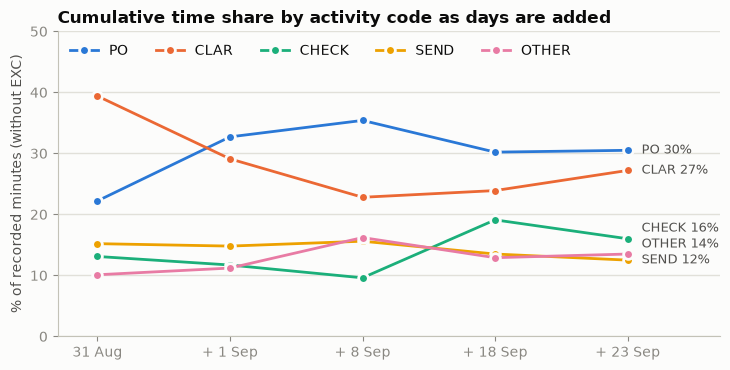

,up to 31 Aug,up to 1 Sep,up to 8 Sep,up to 18 Sep,up to 23 Sep
family,,,,,
PO,22.2,32.7,35.4,30.2,30.5
CLAR,39.4,29.1,22.8,23.9,27.2
CHECK,13.1,11.7,9.6,19.1,16.0
SEND,15.2,14.8,15.6,13.5,12.5
OTHER,10.1,11.2,16.2,12.9,13.5


In [8]:
CODES = ["PO", "CLAR", "CHECK", "SEND", "OTHER"]
b = rows[(rows.timed == 1) & (rows.flag_exc == 0)]
shares = pd.DataFrame({LABEL[d]: b[b.date.isin(DAYS[:i + 1])].groupby("family").minutes.sum()
                       / b[b.date.isin(DAYS[:i + 1])].minutes.sum() * 100 for i, d in enumerate(DAYS)}).reindex(CODES).round(1)

fig, ax = plt.subplots(figsize=(7.5, 3.8))
pos = np.arange(len(DAYS))
for i, code_ in enumerate(CODES):
    ax.plot(pos, shares.loc[code_], color=SERIES[i], marker="o", markeredgecolor="#fcfcfb", markeredgewidth=2, label=code_)
label_y, last = {}, None
for code_ in sorted(CODES, key=lambda c: shares.loc[c].iloc[-1]):   # bottom-up, at least 2.6 points apart
    y = shares.loc[code_].iloc[-1]
    label_y[code_] = y if last is None else max(y, last + 2.6)
    last = label_y[code_]
for code_ in CODES:
    ax.annotate(f"{code_} {shares.loc[code_].iloc[-1]:.0f}%", (pos[-1], label_y[code_]),
                xytext=(10, 0), textcoords="offset points", va="center", color=INK_2, fontsize=9)
ax.set_xticks(pos, ["31 Aug"] + [f"+ {LABEL[d]}" for d in DAYS[1:]])
ax.set_xlim(-0.3, len(DAYS) - 0.3)
ax.set_ylabel("% of recorded minutes (without EXC)")
ax.set_title("Cumulative time share by activity code as days are added")
ax.legend(loc="upper left", ncol=5)
ax.set_ylim(0, 50)
plt.tight_layout()
plt.show()
shares.rename(columns=lambda c: f"up to {c}")

**Reading.** Leaving out any single day keeps the fitted median at about 2 minutes and shifts the fitted curve by at most about 2 percentage points; adding 23 September changed it by the same small amount. PO and CLAR remain the two largest codes without EXC, and adding day 5 moved no code's share by 5 points or more. On this evidence, episode durations and the main time pattern look stable across the five days.

## 3. Saturation: do later days still add new kinds of work?

Each row was given the kinds of work its note supports (31 kinds, such as *check a supplier confirmation* or *retrieve or complete drawings*) in the [kinds-of-work review](Kinds_Of_Work_Review_2026-09-30.md). Here we count, for each day, how many kinds appear **for the first time**. In view B, a kind counts only if it appears in a non-EXC row.

In [9]:
k = kinds.merge(rows[["date", "row", "flag_exc"]], on=["date", "row"])
k["kind_list"] = k.kinds.apply(lambda s: [x for x in s.split(";") if x])

def new_per_day(data):
    first = {}
    for _, r in data.iterrows():
        for kind in r.kind_list:
            first[kind] = min(first.get(kind, 9), DAYS.index(r.date))
    return [sum(1 for v in first.values() if v == i) for i in range(len(DAYS))]

new = {"A. All data": new_per_day(k), "B. Without EXC": new_per_day(k[k.flag_exc == 0])}
sat = pd.DataFrame({f"New kinds, {v}": n for v, n in new.items()}, index=[LABEL[d] for d in DAYS])
for v, n in new.items():
    sat[f"Seen so far, {v}"] = np.cumsum(n)
sat["Rows without a kind"] = [int(((k.date == d) & (k.kinds == "")).sum()) for d in DAYS]
sat["Their minutes"] = [int(rows.merge(k[k.kinds == ""][["date", "row"]], on=["date", "row"]).query("date == @d").minutes.sum()) for d in DAYS]

for v, n in new.items():
    base3, run2 = sum(n[:3]), n[3] + n[4]
    print(f"{v}: days 1–3 as base, days 4–5 as run: {run2} new of {base3} ({run2 / base3:.0%}); "
          f"days 1–4 as base, day 5 as run: {n[4]} new of {sum(n[:4])} ({n[4] / sum(n[:4]):.0%})")
sat.T

A. All data: days 1–3 as base, days 4–5 as run: 5 new of 26 (19%); days 1–4 as base, day 5 as run: 0 new of 31 (0%)
B. Without EXC: days 1–3 as base, days 4–5 as run: 4 new of 25 (16%); days 1–4 as base, day 5 as run: 0 new of 29 (0%)


,31 Aug,1 Sep,8 Sep,18 Sep,23 Sep
"New kinds, A. All data",14,9,3,5,0
"New kinds, B. Without EXC",13,7,5,4,0
"Seen so far, A. All data",14,23,26,31,31
"Seen so far, B. Without EXC",13,20,25,29,29
Rows without a kind,1,0,2,2,7
Their minutes,0,0,4,2,24


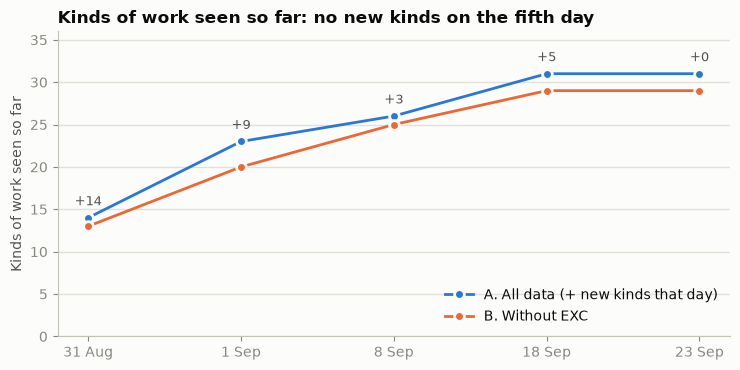

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
pos = np.arange(len(DAYS))
for i, (v, n) in enumerate(new.items()):
    cum = np.cumsum(n)
    ax.plot(pos, cum, color=SERIES[i], marker="o", markeredgecolor="#fcfcfb", markeredgewidth=2,
            label=v + (" (+ new kinds that day)" if i == 0 else ""))
    if i == 0:
        for p_, c_, n_ in zip(pos, cum, n):
            ax.annotate(f"+{n_}", (p_, c_), xytext=(0, 9), textcoords="offset points", ha="center", color=INK_2, fontsize=9)
ax.set_xticks(pos, [LABEL[d] for d in DAYS])
ax.set_ylim(0, 36)
ax.set_ylabel("Kinds of work seen so far")
ax.set_title("Kinds of work seen so far: no new kinds on the fifth day")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Reading.** New kinds of work per day fall from 14 and 9 on the first two days to 0 on 23 September (view A). With days 1–4 as the base, day 5 adds nothing new; with days 1–3 as the base, days 4–5 add 5 kinds (19%), all on 18 September: approval handling, drawings, price discrepancies, certification arrangements and certificates. The later days mainly added **detail inside kinds already seen**, such as unpaid invoices blocking a price check, approval repeated after a pre-order mismatch, and drawing sets missing parts from Engineering.

**Limits.** The base-and-run counting adapts Guest, Namey and Chen (2020), who tested it on interviews (bases of 4–6, runs of 2–3) and call 5% an optional benchmark; applying it to observation days is this project's adaptation. On 23 September, 7 rows (24 minutes) have too little detail to classify, so "0 new" does not prove that nothing new happened. What each kind adds is judged in the kinds-of-work review, and that judgement matters more than the percentage.

## 4. Summary for the discussion

- **Fit:** episode durations are right-skewed and follow a **lognormal** distribution (best by AIC in both views, no misfit in the observed-versus-expected check). A typical episode lasts about 2 minutes.
- **Stability:** leaving out any one day hardly changes the fitted distribution (at most about 2 percentage points), and PO and CLAR stay the two largest codes without EXC.
- **Saturation:** new kinds of work per day fall to 0 on the fifth day; later days add detail rather than new kinds of work.
- **Proposal:** pause broad observation and start the analysis; collect extra data only where a shortlisted candidate needs it.
- **Open:** how to treat EXC, and what comparison with Dennis is expected.